## EDA Exploratory Data Analysis - & - Modeling

Para la implementación del modelo más confiable que se adapate a los datos se exploraron 3 modelos principales de regresiones. Inicialmente se realiza la exploración de los datos con validación de datos nulos, tipos de datos, variables correlacionadas y escalado de variables numericas. En la sección 5 se evalúan los modelos de Regresión Lineal, Random Forest y XGBoost para la comparación de los mejores resultados con el dataset dado. Lo anterior según las métricas de evaluación R2,	Adjusted R2, Cross Validated R2 y RMSE. 

Para el entrenamiento y ajuste de los modelos y su evaluación, se dividió el dataset en 70% para datos de entrenamiento y 30% para datos de validación. 

Como conclusión se elige el modelo XGBoost para la regresión en la predicción del valor medio de vivienda, ya que presenta mejor desempeño en los datos de validación.

### 1. Data Exploration and Cleaning 

In [46]:
import pandas as pd 
df=pd.read_csv("../../data/raw/HousingData.csv")

print("Dataframe size:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Dataframe size: (506, 14)
Columns: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


- **CRIM**: Tasa de criminalidad per cápita por zona residencial.
- **ZN**: Proporción de terrenos residenciales divididos en lotes de más de 25,000 pies cuadrados.
- **INDUS**: Proporción de acres comerciales no minoristas por ciudad.
- **CHAS**: Variable que indica si el tramo limita con el río Charles (1 sí, 0 no).
- **NOX**: Concentración de óxidos de nitrógeno (partes por 10 millones).
- **RM**: Promedio de habitaciones por vivienda.
- **AGE**: Proporción de unidades ocupadas por propietarios construidas antes de 1940.
- **DIS**: Distancia ponderada a cinco centros de empleo de Boston.
- **RAD**: Índice de accesibilidad a autopistas radiales.
- **TAX**: Tasa de impuesto a la propiedad por cada $10,000.
- **PTRATIO**: Proporción de alumnos por profesor en cada ciudad.
- **B**: 1000(Bk - 0.63)^2, donde Bk es la proporción de residentes afroamericanos por ciudad.
- **LSTAT**: Porcentaje de estatus bajo de la población.
- **MEDV**: Valor medio de las viviendas ocupadas por propietarios (en miles de dólares).

In [47]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [49]:
df = df.dropna()
print("Dataframe size after dropping rows with nulls:", df.shape)
print("Valores nullos:", df.isna().sum())

Dataframe size after dropping rows with nulls: (394, 14)
Valores nullos: CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


### 2. Correlation Analysis

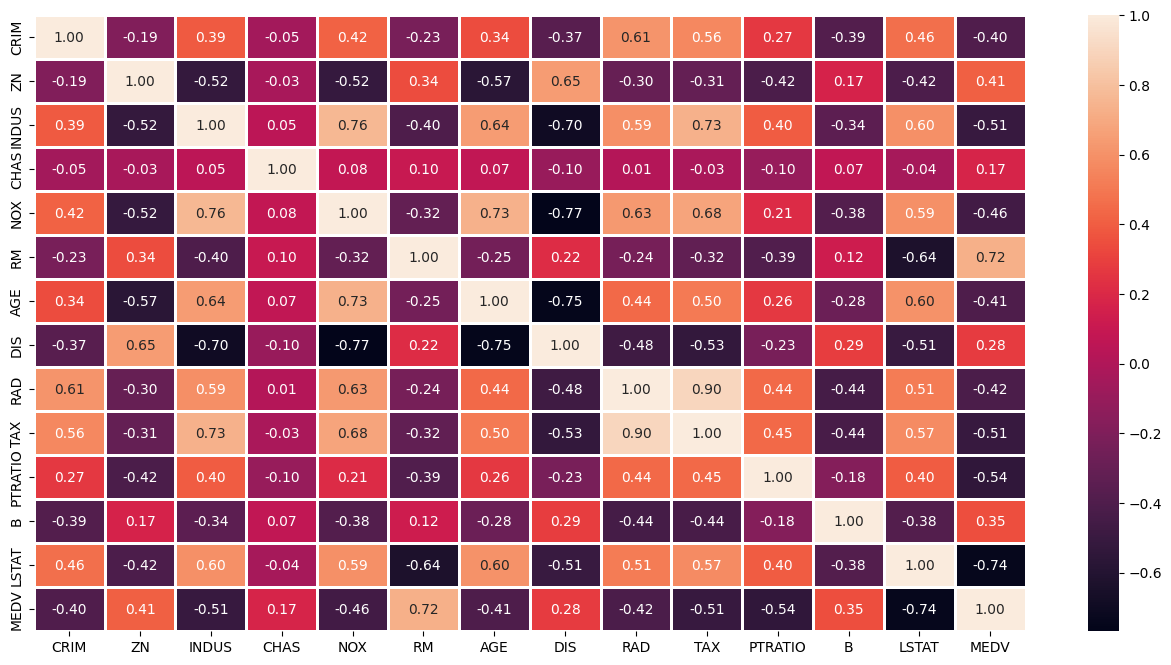

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
# Heatmap
fig, ax = plt.subplots(figsize = (16, 8))
sns.heatmap(df.corr(), annot = True, fmt = '1.2f', annot_kws = {'size' : 10}, linewidth = 1)
plt.show()

In [51]:
df = df.drop(columns='RAD')
print("Size after dropping 'RAD':", df.shape)
df.head()

Size after dropping 'RAD': (394, 13)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,222,18.7,394.63,2.94,33.4
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,222,18.7,394.12,5.21,28.7



### 3. Visualización de outliers con boxplot

In [52]:
numeric_cols = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX', 'PTRATIO', 'B', 'LSTAT']

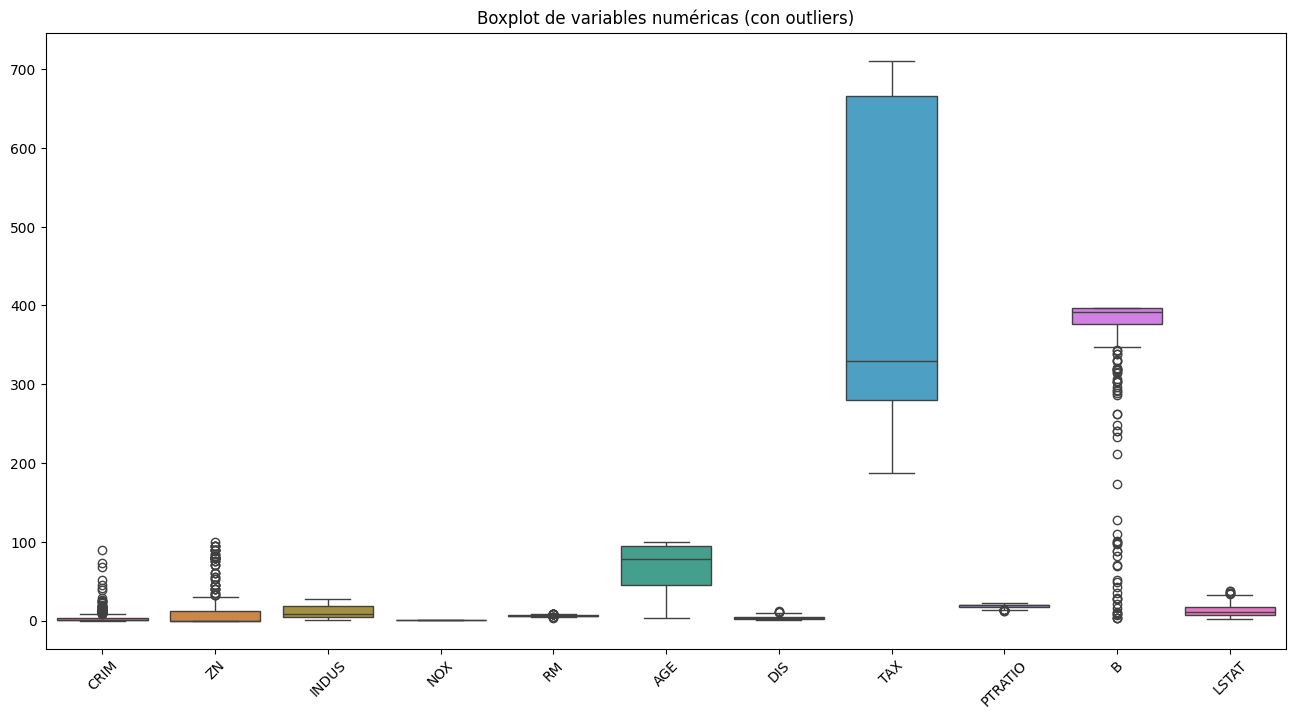

In [53]:
# Boxplot para todas las variables numéricas
plt.figure(figsize=(16,8))
sns.boxplot(data=df[numeric_cols])
plt.title('Boxplot de variables numéricas (con outliers)')
plt.xticks(rotation=45)
plt.show()

In [54]:
# creating features and label variable
X = df.drop(columns = 'MEDV', axis = 1)
y = df['MEDV']
X.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,222,18.7,394.63,2.94
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,222,18.7,394.12,5.21


### 4. Scaling Variables

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.30, random_state = 42)


### 5. Modeling - Linear, Random Forest, XGBoost

In [57]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

def evaluation_metrics(model,X_train,y_train,X_test,y_test,y_pred):
    cv_score = cross_val_score(estimator = model, X = X_train, y = y_train, cv = 10)
    r2 = model.score(X_test, y_test)
    n = X_test.shape[0]
    p = X_test.shape[1]
    adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
    RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
    R2 = model.score(X_test, y_test)
    CV_R2 = cv_score.mean()
    print('RMSE:', round(RMSE,4))
    print('R2:', round(R2,4))
    print('Adjusted R2:', round(adjusted_r2, 4) )
    print("Cross Validated R2: ", round(cv_score.mean(),4) )
    return R2, adjusted_r2, CV_R2, RMSE

linreg = LinearRegression()
linreg.fit(X_train, y_train)
y_pred_linreg = linreg.predict(X_test)
ndf_linreg = [evaluation_metrics(linreg, X_train, y_train, X_test, y_test, y_pred_linreg)]
linreg_score = pd.DataFrame(data=ndf_linreg, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
linreg_score.insert(0, 'Model', 'LinearRegression')
linreg_score

RMSE: 5.4849
R2: 0.6775
Adjusted R2: 0.641
Cross Validated R2:  0.7275


,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,LinearRegression,0.677514,0.641006,0.727542,5.484877


In [58]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
ndf_rf = [evaluation_metrics(rf, X_train, y_train, X_test, y_test, y_pred_rf)]
rf_score = pd.DataFrame(data=ndf_rf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
rf_score.insert(0, 'Model', 'RandomForest')
rf_score

RMSE: 4.4542
R2: 0.7873
Adjusted R2: 0.7633
Cross Validated R2:  0.8222


,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,RandomForest,0.787328,0.763252,0.822156,4.454169


In [59]:
import pandas as pd
from xgboost import XGBRegressor

XGBR = XGBRegressor(n_estimators=500, max_depth=7, eta=0.1, subsample=0.8, colsample_bytree=0.8)
XGBR.fit(X_train, y_train)
y_pred_xgbr = XGBR.predict(X_test)
ndf_xgbr = [evaluation_metrics(XGBR, X_train, y_train, X_test, y_test, y_pred_xgbr)]
xgbr_score = pd.DataFrame(data=ndf_xgbr, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
xgbr_score.insert(0, 'Model', 'XGBoost')
xgbr_score

RMSE: 4.4515
R2: 0.7876
Adjusted R2: 0.7635
Cross Validated R2:  0.8612


,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,XGBoost,0.787584,0.763537,0.86119,4.451481


In [60]:
predictions = pd.concat([linreg_score, rf_score, xgbr_score], ignore_index=True, sort=False)
predictions

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,LinearRegression,0.677514,0.641006,0.727542,5.484877
1,RandomForest,0.787328,0.763252,0.822156,4.454169
2,XGBoost,0.787584,0.763537,0.861190,4.451481
